In [7]:
import numpy as np
import torch
from sbi.utils import BoxUniform
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import sys
sys.path.insert(1,'../')
from inference_utils import get_prior
from simulators import CLASSIC_WF as simulator
from simulators import wrapper, wrapper_hierarchical
prior = get_prior('CLASSIC_WF')

# ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# simulate test_theta in wrapper and wrapper hierarchical and export as .pt

test_theta = torch.load("tests/test_theta.pt")
test_x = torch.empty(test_theta.shape[0], 10, 21)
test_x_h = torch.empty(test_theta.shape[0], 10, 21)

for i in range(test_theta.shape[0]):
    test_x[i] = wrapper(simulator, 10, test_theta[i])
    test_x_h[i] = wrapper_hierarchical(simulator, 10, test_theta[i], var=0.2)

torch.save(test_x, "tests/test_x.pt")
torch.save(test_x_h, "tests/test_x_h.pt")

In [ ]:
# sbi imports
from sbi.inference import NPE, simulate_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import sys
sys.path.append("../")
# from simulators import wrapper, GORDO

# def sim_iid(theta):
#     return wrapper(GORDO, reps=10, parameters=theta)


# Sample 500 parameter sets
num_samples = 500

# Check prior, return PyTorch prior.
prior, num_parameters, prior_returns_numpy = process_prior(prior)

# Check simulator, returns PyTorch simulator able to simulate batches.
sbi_simulator = process_simulator(simulator, prior, prior_returns_numpy)


# Generate training data
theta, x = simulate_for_sbi(sbi_simulator, proposal=prior, num_simulations=num_samples, num_workers=80)
theta_test = theta[x[:,-1] > 0.1]
print(x.shape, theta.shape)
torch.save(theta_test, "test_theta.pt")
torch.save(x_test, "test_x.pt")
print(x_test.shape, theta_test.shape)

  0%|          | 0/500 [00:00<?, ?it/s]

torch.Size([500, 21]) torch.Size([500, 3])
torch.Size([124, 21]) torch.Size([124, 3])


In [ ]:
# Load saved data
train_theta = torch.load("train_theta.pt")
train_x = torch.load("train_x.pt").squeeze(1)  # shape: (num_samples, reps, features) or (num_samples, features) if reps squeezed


# Train NPE
inference = NPE(prior=prior)
density_estimator = inference.append_simulations(train_theta, train_x).train()
posterior = inference.build_posterior(density_estimator)

# Save the posterior model
import pickle
with open("posterior_singles.pkl", "wb") as f:
    pickle.dump(posterior, f)

2025-10-12 19:42:01.880767: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-12 19:42:02.929052: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


 Training neural network. Epochs trained: 53

In [ ]:
# load the posterior model
import pickle
with open("posterior_singles.pkl", "rb") as f:
    posterior = pickle.load(f)

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

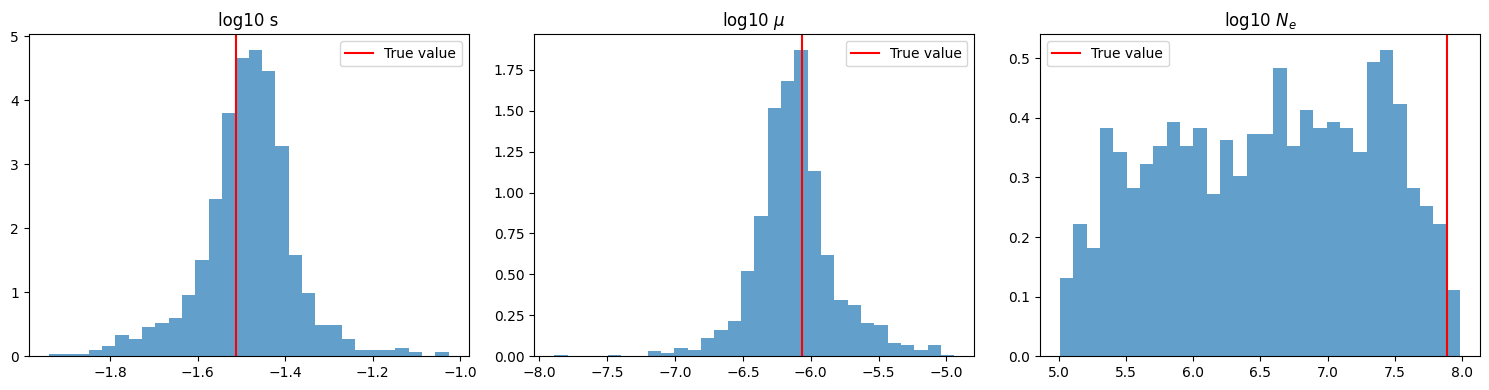

In [48]:
train_theta = torch.load("train_theta.pt")
theta = prior.sample((1,)).squeeze() # Example parameters in log10 space
samples = posterior.set_default_x(simulator(theta)).sample((1000,))
param_names = ["log10 s", "log10 $\mu$", "log10 $N_e$"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.hist(samples[:, i].numpy(), bins=30, density=True, alpha=0.7)
    ax.axvline(theta[i], color='red', label='True value')
    ax.set_title(param_names[i])
    ax.legend()
plt.tight_layout()
plt.show()

Rejection Sampling: 1023it [00:09, 111.00it/s]                         


Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

Drawing 1000 posterior samples:   0%|          | 0/1000 [00:00<?, ?it/s]

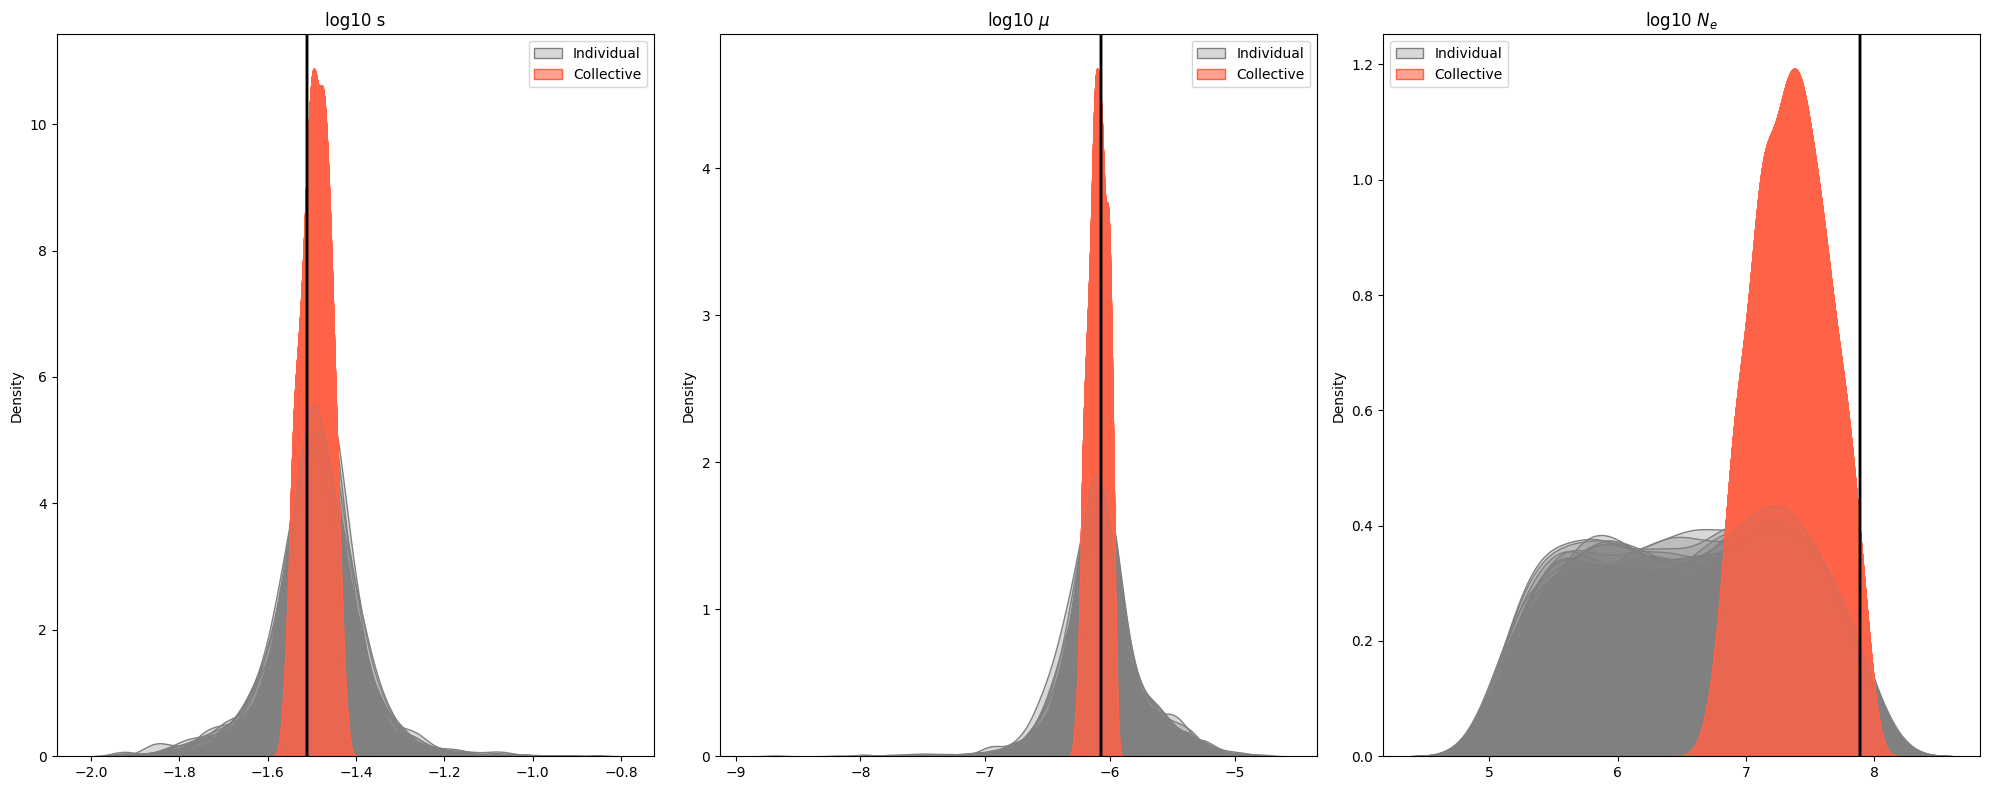

In [56]:
import sys
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from seaborn import kdeplot

x = torch.cat([simulator(theta).reshape(1, -1) for _ in range(12)], dim=0)
# x = x + torch.randn_like(x) * 0.01  # Add some noise to the observations
op = CollectivePosterior(prior, x, posterior, 1, -50)
op.get_log_C()
samps = op.sample(1000)

# samps_pie = posterior_pie.set_default_x(x).sample((1000,))

param_names = ["log10 s", "log10 $\mu$", "log10 $N_e$"]
fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for j in range(len(x)):
    samples = posterior.set_default_x(x[j]).sample((1000,))
    for i, ax in enumerate(axes):
        kdeplot(samples[:, i].numpy(), fill=True, alpha=0.3, label='Individual' if j==0 else '', ax=ax, color='grey')
        kdeplot(samps[:, i].numpy(), fill=True, alpha=0.6, label='Collective' if j==0 else '', ax=ax, color='tomato')
        # kdeplot(samps_pie[:, i].numpy(), fill=True, alpha=0.5, label='NPE+PIE', ax=ax)
        ax.axvline(theta[i], color='k')
        ax.set_title(param_names[i])
        ax.legend()
plt.tight_layout()
plt.show()